In [96]:
text_triples =  [
["former Arsenal goalkeeper", "played for", "Royals"],
["former Arsenal goalkeeper", "appointed as", "youth academy director"],
["former Arsenal goalkeeper", "appointed as", "director of football"],
["youth academy director", "started in", "2000"],
["director of football", "started in", "2003"],
["West Brom", "issued", "statement"],
["former Arsenal goalkeeper", "played a key role in", "Championship club"],
["Championship club", "won promotion to", "Premier League"],
["promotion to Premier League", "occurred in", "2006"],
["promotion to Premier League", "occurred in", "2012"]
]

summary_triples =[
["Nick Hammond", "held position of", "Reading director of football"],
["West Bromwich Albion", "appointed", "Nick Hammond"],
["Nick Hammond", "is", "head coach of West Bromwich Albion"]
]

In [ ]:
gpt_oss = [ ["fire alarm", "went off at", "Holiday Inn on Hope Street"], 
                    ["fire alarm", "went off at time", "04:20 BST on Saturday"], 
                    ["guests", "were asked to leave", "hotel"], 
                    ["buses", "engulfed by", "flames"], 
                    ["German tour group", "origin", "Germany"], 
                    ["Chinese/Taiwanese tour group", "origin", "China and Taiwan"], 
                    ["tour groups", "first night in", "Northern Ireland"], 
                    ["passengers", "left personal belongings on", "bus"], 
                    ["personal belongings", "were destroyed by", "fire"], 
                    ["both groups", "organised", "replacement coaches"], 
                    ["replacement coaches", "will begin tour of", "north coast"], 
                    ["police", "appealed for information about", "attack"], 
                    ["Insp David Gibson", "said fire started under", "one bus"], 
                    ["fire", "spread to", "second bus"], 
                    ["fire", "was thought to be started deliberately", "investigation"] ]

gpt_5 = [ ["fire alarm", "went off at", "Holiday Inn in Hope Street"], 
         ["fire alarm", "went off at", "04:20 BST on Saturday"], 
         ["Holiday Inn", "located in", "Hope Street"], 
         ["guests", "asked to leave", "Holiday Inn"], 
         ["two buses", "parked in", "car park of Holiday Inn"], 
         ["two buses", "engulfed by", "flames"], 
         ["one tour group", "origin", "Germany"], 
         ["other tour group", "origin", "China and Taiwan"], 
         ["tour groups", "staying in", "Northern Ireland"], 
         ["driver of one of the buses", "reported", "personal belongings destroyed"], 
         ["personal belongings", "left on board", "buses"], 
         ["both groups", "organised", "replacement coaches"], 
         ["both groups", "will begin tour of", "north coast"], 
            ["Police", "appealed for", "information about the attack"], 
            ["Insp David Gibson", "stated", "fire started under one of the buses before spreading to the second"], 
            ["fire", "thought to be started", "deliberately"], 
                ["exact cause of fire", "is", "under investigation"] ]

In [12]:
import networkx as nx
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

class KGPathFinder:
    def __init__(self, similarity_threshold=0.85):
        self.model = SentenceTransformer('all-MiniLM-L6-v2')
        self.threshold = similarity_threshold
    
    def build_graph(self, triplets):
        """
        Build directed graph from triplets
        triplets: [("subject", "predicate", "object"), ...]
        """
        G = nx.DiGraph()
        
        for subj, pred, obj in triplets:
            # Add nodes with embeddings
            if subj not in G:
                G.add_node(subj, embedding=self.model.encode(subj))
            if obj not in G:
                G.add_node(obj, embedding=self.model.encode(obj))
            
            # Add edge with relation
            G.add_edge(subj, obj, relation=pred)
        
        return G
    
    def find_similar_node(self, query_node, graph):
        """
        Find nodes in graph similar to query_node
        """
        query_emb = self.model.encode(query_node)
        similar_nodes = []
        all_list = []
        
        for node in graph.nodes():
            node_emb = graph.nodes[node]['embedding']
            sim = cosine_similarity(
                query_emb.reshape(1, -1), 
                node_emb.reshape(1, -1)
            )[0][0]

            all_list.append((node, sim))
            # print(f"Similarity between '{query_node}' and '{node}': {sim:.4f}")
            
            # if sim > self.threshold:
            #     similar_nodes.append((node, sim))

        high_sim = sorted(all_list, key=lambda x: x[1], reverse=True)[:5]
        similar_nodes.extend(high_sim)
        
        return sorted(similar_nodes, key=lambda x: x[1], reverse=True)
    
    def find_paths(self, summary_triplet, doc_graph, max_hops=3):
        """
        Find all paths supporting the summary triplet
        """
        sum_subj, sum_pred, sum_obj = summary_triplet
        
        results = []
        
        # 1. DIRECT MATCH
        direct = self._find_direct_match(sum_subj, sum_pred, sum_obj, doc_graph)
        if direct:
            results.append(direct)
        
        # 2. SEMANTIC MATCH (similar entities, similar relation)
        semantic = self._find_semantic_match(sum_subj, sum_pred, sum_obj, doc_graph)
        if semantic:
            results.extend(semantic)
        
        # 3. MULTI-HOP PATHS
        multihop = self._find_multihop_paths(sum_subj, sum_obj, doc_graph, max_hops)
        if multihop:
            results.extend(multihop)
        
        return results
    
    def _find_direct_match(self, subj, pred, obj, graph):
        """Check if exact triplet exists"""
        # print("Checking direct match for:", subj, pred, obj)
        if graph.has_edge(subj, obj):
            edge_data = graph.get_edge_data(subj, obj)
            if edge_data['relation'] == pred:
                return {
                    'type': 'direct_match',
                    'confidence': 1.0,
                    'path': [(subj, pred, obj)],
                    'hops': 1
                }
        return None
    
    def _find_semantic_match(self, subj, pred, obj, graph):
        """Find semantically similar triplets"""
        results = []

        # print("Checking semantic match for:", subj, pred, obj)
        
        # Find similar subject and object nodes
        similar_subjs = self.find_similar_node(subj, graph)
        similar_objs = self.find_similar_node(obj, graph)
        
        pred_emb = self.model.encode(pred)
        
        for doc_subj, subj_sim in similar_subjs[:3]:  # Top 3
            for doc_obj, obj_sim in similar_objs[:3]:
                if graph.has_edge(doc_subj, doc_obj):
                    edge_data = graph.get_edge_data(doc_subj, doc_obj)
                    doc_pred = edge_data['relation']
                    
                    # Check predicate similarity
                    doc_pred_emb = self.model.encode(doc_pred)
                    pred_sim = cosine_similarity(
                        pred_emb.reshape(1, -1),
                        doc_pred_emb.reshape(1, -1)
                    )[0][0]

                    # print(f"Predicate similarity between '{pred}' and '{doc_pred}': {pred_sim:.4f}")
                    
                    # if pred_sim > self.threshold:
                    confidence = (subj_sim + obj_sim + pred_sim) / 3
                    results.append({
                        'type': 'semantic_match',
                        'confidence': float(confidence),
                        'path': [(doc_subj, doc_pred, doc_obj)],
                        'hops': 1,
                        'mapping': {
                            'subject': f"{subj} → {doc_subj} (sim: {subj_sim:.2f})",
                            'predicate': f"{pred} → {doc_pred} (sim: {pred_sim:.2f})",
                            'object': f"{obj} → {doc_obj} (sim: {obj_sim:.2f})"
                        }
                    })
        
        return results
    
    def _find_multihop_paths(self, subj, obj, graph, max_hops):
        """Find multi-hop reasoning paths"""
        results = []

        # print("Checking multi-hop paths for:", subj, obj)
        
        # Find similar entities in graph
        similar_subjs = self.find_similar_node(subj, graph)
        similar_objs = self.find_similar_node(obj, graph)
        
        for doc_subj, subj_sim in similar_subjs[:3]:
            for doc_obj, obj_sim in similar_objs[:3]:
                try:
                    # Find all simple paths up to max_hops
                    paths = nx.all_simple_paths(
                        graph, 
                        doc_subj, 
                        doc_obj, 
                        cutoff=max_hops
                    )
                   
                    
                    for path in paths:
                        print(path) 
                        if len(path) > 2:
                             # Multi-hop only
                            triplet_path = self._path_to_triplets(path, graph)
                            
                            # Calculate confidence (decreases with hops)
                            confidence = (subj_sim + obj_sim) / 2
                            confidence *= (0.9 ** (len(path) - 2))  # Decay
                            
                            results.append({
                                'type': 'multi_hop',
                                'confidence': float(confidence),
                                'path': triplet_path,
                                'hops': len(path) - 1,
                                'reasoning': self._explain_path(triplet_path)
                            })
                
                except nx.NetworkXNoPath:
                    continue
        
        # Sort by confidence
        return sorted(results, key=lambda x: x['confidence'], reverse=True)[:5]
    
    def _path_to_triplets(self, node_path, graph):
        """Convert node path to list of triplets"""
        triplets = []
        for i in range(len(node_path) - 1):
            u, v = node_path[i], node_path[i + 1]
            edge_data = graph.get_edge_data(u, v)
            triplets.append((u, edge_data['relation'], v))
        return triplets
    
    def _explain_path(self, triplet_path):
        """Generate human-readable explanation of path"""
        steps = []
        for i, (s, p, o) in enumerate(triplet_path, 1):
            steps.append(f"Step {i}: {s} --[{p}]--> {o}")
        return " → ".join(steps)

In [97]:
finder = KGPathFinder(similarity_threshold=0.80)

# Build graph
doc_graph = finder.build_graph(text_triples)

# Find paths for each summary triplet (don't pass the whole list as a single triplet)
all_paths = {}
for trip in summary_triples:
	if isinstance(trip, (list, tuple)) and len(trip) == 3:
		all_paths[tuple(trip)] = finder.find_paths(trip, doc_graph, max_hops=3)
	else:
		all_paths[tuple(trip) if not isinstance(trip, list) else tuple(trip)] = []

# Provide a flat list of paths as well (if you expect a single variable `paths`)
paths = [item for sublist in all_paths.values() for item in sublist]


/Users/nirashanelki/Documents/Works/Research/codes/factual_inconsistency_validate_xai/.venv/lib/python3.9/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


['former Arsenal goalkeeper', 'director of football']
['former Arsenal goalkeeper', 'Championship club', 'Premier League']
['former Arsenal goalkeeper', 'youth academy director']
['former Arsenal goalkeeper', 'director of football']
['former Arsenal goalkeeper', 'Championship club', 'Premier League']


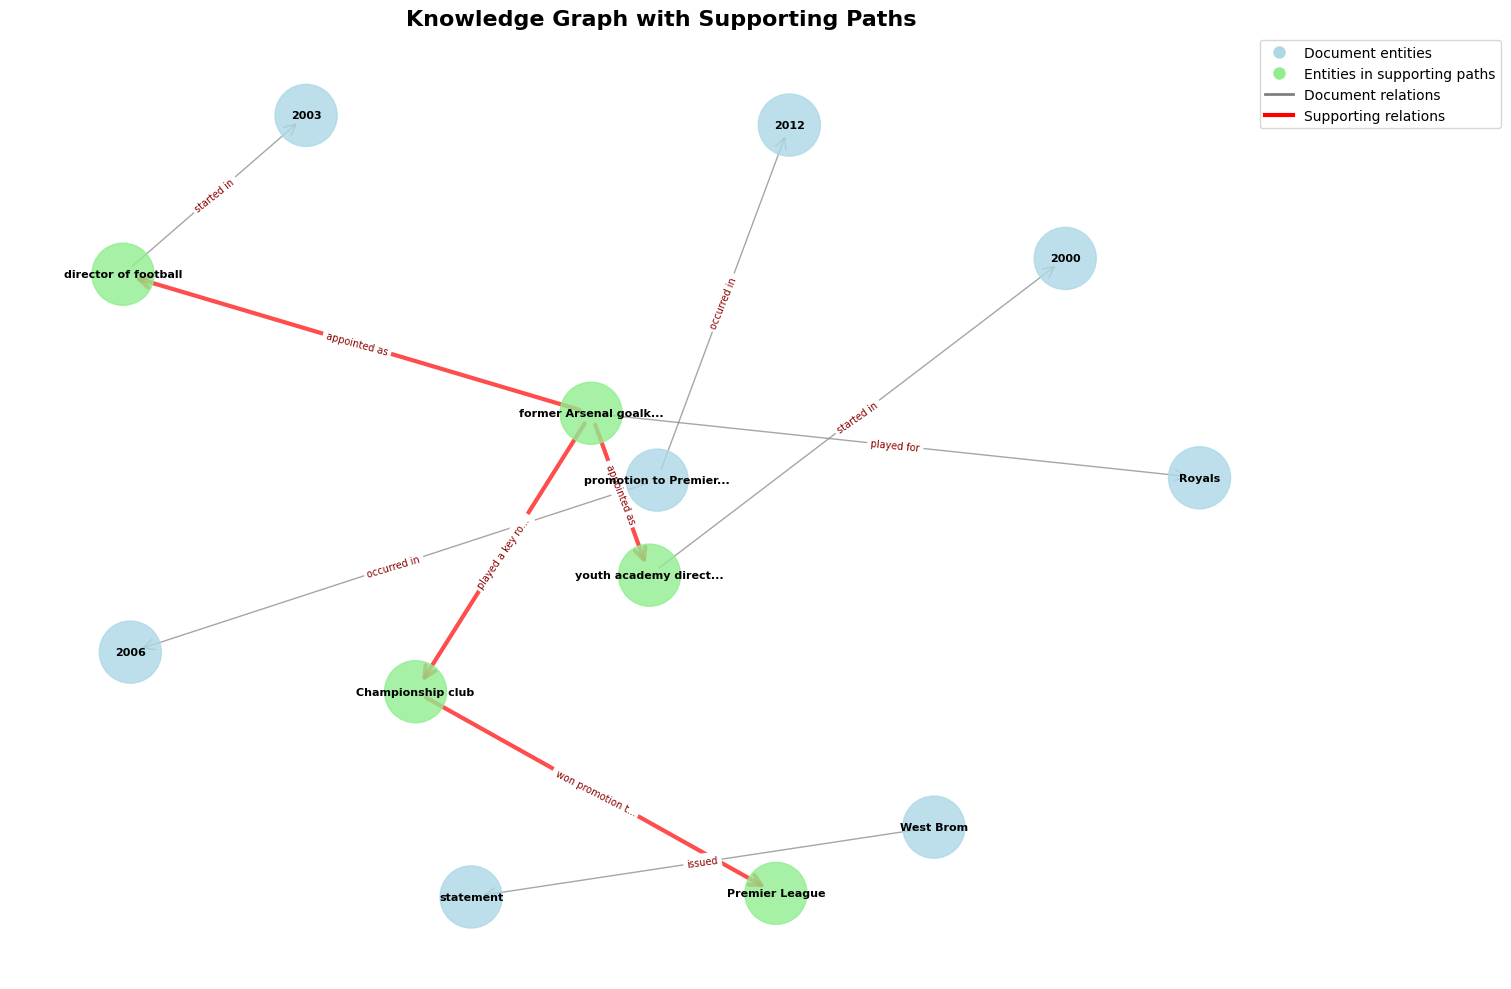

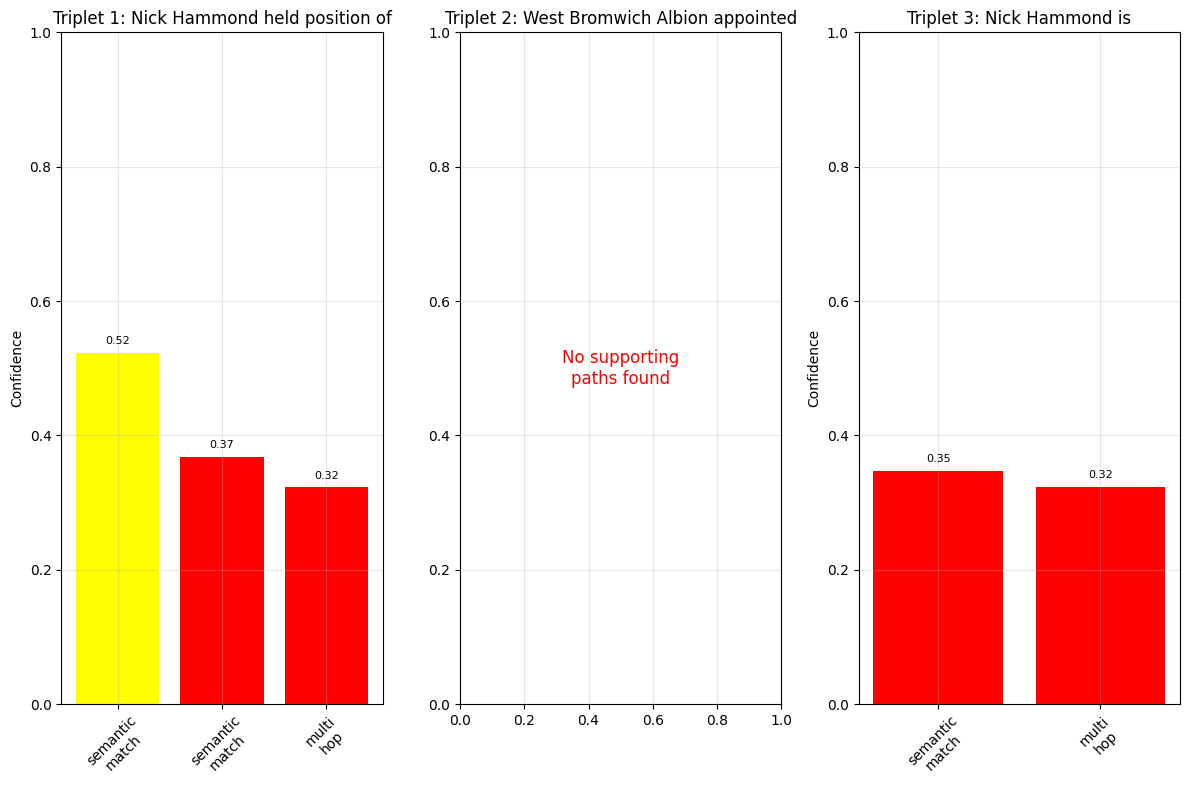

In [98]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_kg_with_paths(finder, doc_graph, summary_triplets, all_paths, 
                           figsize=(15, 10), node_size=2000, font_size=8,
                           highlight_paths=True):
    """
    Visualize the knowledge graph with highlighted paths supporting summary triplets.
    
    Parameters:
    - finder: KGPathFinder instance
    - doc_graph: NetworkX graph from build_graph()
    - summary_triplets: List of summary triplets
    - all_paths: Dictionary of paths found for each summary triplet
    - figsize: Figure size tuple
    - node_size: Size of nodes in visualization
    - font_size: Font size for labels
    - highlight_paths: Whether to highlight supporting paths
    """
    plt.figure(figsize=figsize)
    
    # Create layout
    pos = nx.spring_layout(doc_graph, seed=42, k=1, iterations=50)
    
    # Default colors
    node_colors = ['lightblue'] * len(doc_graph.nodes())
    edge_colors = ['gray'] * len(doc_graph.edges())
    edge_widths = [1] * len(doc_graph.edges())
    
    if highlight_paths:
        # Color nodes and edges involved in supporting paths
        highlighted_nodes = set()
        highlighted_edges = set()
        
        # Collect all nodes and edges from supporting paths
        for sum_trip, path_list in all_paths.items():
            for path_info in path_list:
                for triplet in path_info['path']:
                    subj, pred, obj = triplet
                    highlighted_nodes.add(subj)
                    highlighted_nodes.add(obj)
                    if doc_graph.has_edge(subj, obj):
                        highlighted_edges.add((subj, obj))
        
        # Update colors for highlighted elements
        node_list = list(doc_graph.nodes())
        for i, node in enumerate(node_list):
            if node in highlighted_nodes:
                node_colors[i] = 'lightgreen'
        
        edge_list = list(doc_graph.edges())
        for i, edge in enumerate(edge_list):
            if edge in highlighted_edges:
                edge_colors[i] = 'red'
                edge_widths[i] = 3
    
    # Draw the graph
    nx.draw_networkx_nodes(doc_graph, pos, 
                          node_color=node_colors, 
                          node_size=node_size, 
                          alpha=0.8)
    
    nx.draw_networkx_edges(doc_graph, pos,
                          edge_color=edge_colors,
                          width=edge_widths,
                          arrowstyle='->', 
                          arrowsize=20,
                          alpha=0.7)
    
    # Add labels with text wrapping for long labels
    labels = {}
    for node in doc_graph.nodes():
        if len(node) > 20:
            # Wrap long labels
            words = node.split()
            if len(words) > 3:
                labels[node] = ' '.join(words[:3]) + '...'
            else:
                labels[node] = node[:20] + '...' if len(node) > 20 else node
        else:
            labels[node] = node
    
    nx.draw_networkx_labels(doc_graph, pos, labels, 
                           font_size=font_size, 
                           font_weight="bold")
    
    # Add edge labels for relations
    edge_labels = {}
    for u, v, data in doc_graph.edges(data=True):
        relation = data.get('relation', '')
        if len(relation) > 15:
            edge_labels[(u, v)] = relation[:15] + '...'
        else:
            edge_labels[(u, v)] = relation
    
    nx.draw_networkx_edge_labels(doc_graph, pos, 
                                edge_labels=edge_labels,
                                font_size=font_size-1,
                                font_color='darkred')
    
    plt.title("Knowledge Graph with Supporting Paths", fontsize=16, fontweight='bold')
    
    # Add legend
    if highlight_paths:
        legend_elements = [
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue', 
                      markersize=10, label='Document entities'),
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgreen', 
                      markersize=10, label='Entities in supporting paths'),
            plt.Line2D([0], [0], color='gray', linewidth=2, label='Document relations'),
            plt.Line2D([0], [0], color='red', linewidth=3, label='Supporting relations')
        ]
        plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.15, 1))
    
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def visualize_summary_support(summary_triplets, all_paths, figsize=(12, 8)):
    """
    Create a summary visualization showing support for each summary triplet.
    """
    n_triplets = len(summary_triplets)
    fig, axes = plt.subplots(1, n_triplets, figsize=figsize)
    
    if n_triplets == 1:
        axes = [axes]
    
    for i, sum_trip in enumerate(summary_triplets):
        ax = axes[i] if n_triplets > 1 else axes[0]
        sum_trip_key = tuple(sum_trip)
        paths = all_paths.get(sum_trip_key, [])
        
        # Create a simple bar chart showing confidence levels
        if paths:
            confidences = [p['confidence'] for p in paths]
            types = [p['type'] for p in paths]
            
            bars = ax.bar(range(len(confidences)), confidences, 
                         color=['green' if c > 0.8 else 'yellow' if c > 0.5 else 'red' 
                               for c in confidences])
            
            ax.set_ylim(0, 1)
            ax.set_ylabel('Confidence')
            ax.set_title(f"Triplet {i+1}: {' '.join(sum_trip[:2])}")
            ax.set_xticks(range(len(types)))
            ax.set_xticklabels([t.replace('_', '\n') for t in types], rotation=45)
            
            # Add confidence values on bars
            for j, (bar, conf) in enumerate(zip(bars, confidences)):
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                       f'{conf:.2f}', ha='center', va='bottom', fontsize=8)
        else:
            ax.text(0.5, 0.5, 'No supporting\npaths found', 
                   ha='center', va='center', transform=ax.transAxes,
                   fontsize=12, color='red')
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.set_title(f"Triplet {i+1}: {' '.join(sum_trip[:2])}")
        
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Visualize the knowledge graph with highlighted supporting paths
visualize_kg_with_paths(finder, doc_graph, summary_triples, all_paths)

# Show summary support visualization
visualize_summary_support(summary_triples, all_paths)

In [99]:
print("Found paths for summary triplets:")
for sum_trip, path_list in all_paths.items():   
    print(f"\nSummary Triplet: {sum_trip}")
    if not path_list:
        print("  No supporting paths found.")
        continue
    for p in path_list:
        print(f"  Type: {p['type']}, Confidence: {p['confidence']:.4f}, Hops: {p['hops']}")
        for t in p['path']:
            print(f"    {t[0]} --[{t[1]}]--> {t[2]}")
        if 'mapping' in p:
            print("    Mappings:")
            for k, v in p['mapping'].items():
                print(f"      {k}: {v}")
        if 'reasoning' in p:
            print(f"    Reasoning: {p['reasoning']}")

Found paths for summary triplets:

Summary Triplet: ('Nick Hammond', 'held position of', 'Reading director of football')
  Type: semantic_match, Confidence: 0.5226, Hops: 1
    former Arsenal goalkeeper --[appointed as]--> director of football
    Mappings:
      subject: Nick Hammond → former Arsenal goalkeeper (sim: 0.28)
      predicate: held position of → appointed as (sim: 0.43)
      object: Reading director of football → director of football (sim: 0.85)
  Type: semantic_match, Confidence: 0.3683, Hops: 1
    former Arsenal goalkeeper --[appointed as]--> youth academy director
    Mappings:
      subject: Nick Hammond → former Arsenal goalkeeper (sim: 0.28)
      predicate: held position of → appointed as (sim: 0.43)
      object: Reading director of football → youth academy director (sim: 0.39)
  Type: multi_hop, Confidence: 0.3225, Hops: 2
    former Arsenal goalkeeper --[played a key role in]--> Championship club
    Championship club --[won promotion to]--> Premier League
   

Found paths for summary triplets:

Summary Triplet: ('Two tourist buses', 'destroyed in', 'Suspected arson attack')
  Type: semantic_match, Confidence: 0.6398, Hops: 1
    Two buses --[damaged by]--> Flames
    Mappings:
      subject: Two tourist buses → Two buses (sim: 0.88)
      predicate: destroyed in → damaged by (sim: 0.60)
      object: Suspected arson attack → Flames (sim: 0.44)
  Type: multi_hop, Confidence: 0.4057, Hops: 2
    Passengers --[left belongings on]--> Two buses
    Two buses --[damaged by]--> Flames
    Reasoning: Step 1: Passengers --[left belongings on]--> Two buses → Step 2: Two buses --[damaged by]--> Flames

Summary Triplet: ('Suspected arson attack', 'occurred in', 'Londonderry')
  Type: multi_hop, Confidence: 0.3760, Hops: 2
    Fire alarm --[activated at]--> Holiday Inn
    Holiday Inn --[located in]--> Hope Street
    Reasoning: Step 1: Fire alarm --[activated at]--> Holiday Inn → Step 2: Holiday Inn --[located in]--> Hope Street